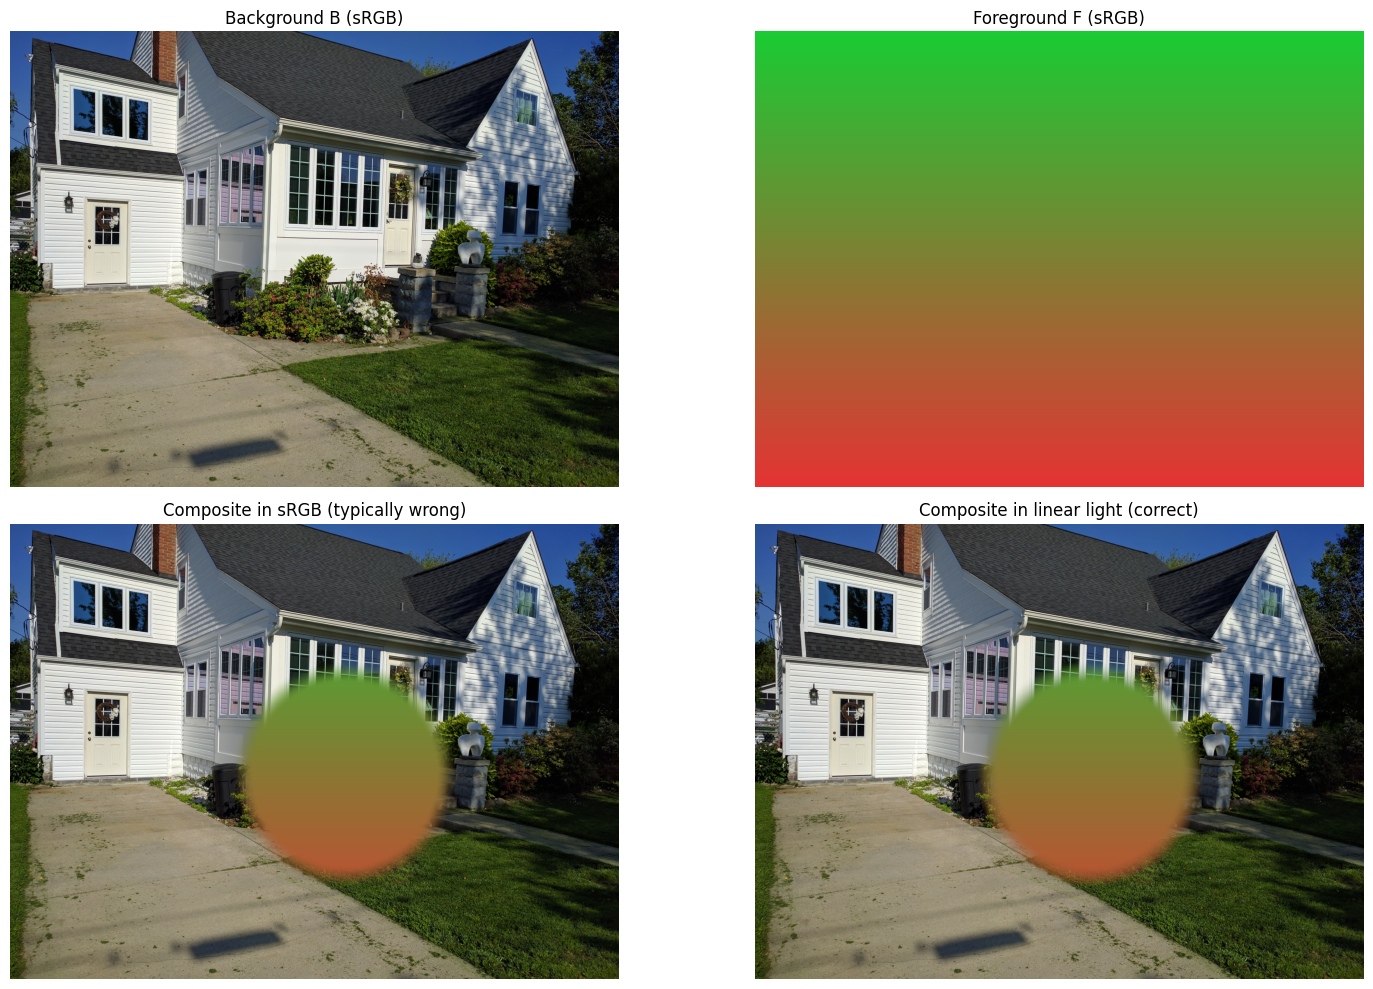

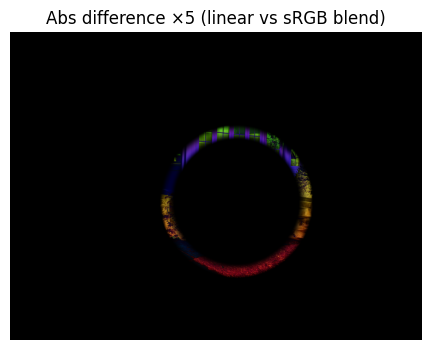

C:\Users\knut1\AppData\Local\Temp\ipykernel_29808\1505392998.py:65: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img8, mode="RGB").save(path)


Saved:
 - .\outputs_ex3_3\composite_srgb.png
 - .\outputs_ex3_3\composite_linear.png
 - .\outputs_ex3_3\difference_x5.png


In [4]:
# Ex 3.3 (1) — Compositing with/without gamma-correction (full runnable code)
# Folder layout assumption:
#   Chapter_3/   <-- your notebook (.ipynb) is here
#   Files/Random_Images/houses_3.jpg  <-- same level as Chapter_3, inside Files/Random_Images

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ----------------------------
# Paths
# ----------------------------
bg_path = os.path.join("..", "Files", "Random_Images", "houses_3.jpg")

# Optional: if you actually have a foreground + alpha matte, put them here and set USE_SYNTHETIC = False
# fg_path = os.path.join("..", "Files", "Random_Images", "foreground.png")   # RGB image
# a_path  = os.path.join("..", "Files", "Random_Images", "alpha.png")        # grayscale alpha (0..255)
USE_SYNTHETIC = True


# ----------------------------
# Helpers
# ----------------------------
def load_rgb_float(path):
    img = Image.open(path).convert("RGB")
    return np.asarray(img).astype(np.float32) / 255.0

def load_alpha_float(path):
    a = Image.open(path).convert("L")
    return np.asarray(a).astype(np.float32) / 255.0

def clip01(x):
    return np.clip(x, 0.0, 1.0)

def srgb_to_linear(E):
    # E in [0,1], sRGB electro-optical transfer function inverse
    a = 0.055
    return np.where(E <= 0.04045, E / 12.92, ((E + a) / (1 + a)) ** 2.4)

def linear_to_srgb(L):
    a = 0.055
    return np.where(L <= 0.0031308, 12.92 * L, (1 + a) * (L ** (1 / 2.4)) - a)

def composite_over_srgb(F_srgb, B_srgb, A):
    """
    WRONG (in general): blends gamma-encoded values directly.
    C = A*F + (1-A)*B, but done in sRGB/gamma space.
    """
    A3 = A[..., None]
    return clip01(A3 * F_srgb + (1.0 - A3) * B_srgb)

def composite_over_linear(F_srgb, B_srgb, A):
    """
    Correct: convert to linear light, blend, convert back to sRGB.
    """
    FL = srgb_to_linear(F_srgb)
    BL = srgb_to_linear(B_srgb)
    A3 = A[..., None]
    CL = A3 * FL + (1.0 - A3) * BL
    return clip01(linear_to_srgb(clip01(CL)))

def save_rgb(path, img01):
    img8 = (clip01(img01) * 255.0 + 0.5).astype(np.uint8)
    Image.fromarray(img8, mode="RGB").save(path)


# ----------------------------
# Build inputs
# ----------------------------
B = load_rgb_float(bg_path)
H, W, _ = B.shape

if USE_SYNTHETIC:
    # Make a synthetic foreground and alpha matte so the code runs with only houses_3.jpg.
    # Foreground: a colored rectangle with a subtle vertical gradient (looks "object-like")
    F = np.zeros((H, W, 3), dtype=np.float32)
    color_top = np.array([0.1, 0.8, 0.2], dtype=np.float32)   # green-ish
    color_bot = np.array([0.9, 0.2, 0.2], dtype=np.float32)   # red-ish
    t = np.linspace(0, 1, H, dtype=np.float32)[:, None]       # (H,1)
    grad = (1 - t) * color_top + t * color_bot                # (H,3) via broadcasting
    F[:] = grad[:, None, :]                                   # (H,W,3)

    # Alpha: a feathered circle in the center (soft edges show the gamma issue clearly)
    yy, xx = np.mgrid[0:H, 0:W]
    cy, cx = H * 0.55, W * 0.55
    r = min(H, W) * 0.25
    dist = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

    # Smoothstep edge from 1 inside to 0 outside over a band
    edge = r * 0.20
    A = (r - dist) / edge
    A = clip01(A)
    # smoothstep: 3x^2 - 2x^3
    A = A * A * (3 - 2 * A)

else:
    # If you have real data:
    # F = load_rgb_float(fg_path)
    # A = load_alpha_float(a_path)
    # And make sure sizes match B (resize if needed).
    raise RuntimeError("Set USE_SYNTHETIC=True unless you provide fg_path and a_path.")


# ----------------------------
# Composite both ways
# ----------------------------
C_srgb   = composite_over_srgb(F, B, A)      # blending in gamma space (usually wrong)
C_linear = composite_over_linear(F, B, A)    # correct linear-light blending

diff = clip01(np.abs(C_linear - C_srgb) * 5.0)  # magnify differences so you can see them

# ----------------------------
# Display
# ----------------------------
plt.figure(figsize=(16, 10))
plt.subplot(2, 2, 1); plt.imshow(B);        plt.title("Background B (sRGB)"); plt.axis("off")
plt.subplot(2, 2, 2); plt.imshow(F);        plt.title("Foreground F (sRGB)"); plt.axis("off")
plt.subplot(2, 2, 3); plt.imshow(C_srgb);   plt.title("Composite in sRGB (typically wrong)"); plt.axis("off")
plt.subplot(2, 2, 4); plt.imshow(C_linear); plt.title("Composite in linear light (correct)"); plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.imshow(diff); plt.title("Abs difference ×5 (linear vs sRGB blend)"); plt.axis("off")
plt.show()

# ----------------------------
# Save outputs
# ----------------------------
out_dir = os.path.join(".", "outputs_ex3_3")
os.makedirs(out_dir, exist_ok=True)

save_rgb(os.path.join(out_dir, "composite_srgb.png"), C_srgb)
save_rgb(os.path.join(out_dir, "composite_linear.png"), C_linear)
save_rgb(os.path.join(out_dir, "difference_x5.png"), diff)

print("Saved:")
print(" -", os.path.join(out_dir, "composite_srgb.png"))
print(" -", os.path.join(out_dir, "composite_linear.png"))
print(" -", os.path.join(out_dir, "difference_x5.png"))
